# Gaussian Process

This demo shows how to use GaussianProcessRegressor to regress the MET efficiency (MET<50) three-jet events, with respect to the jet-energy scales.

In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

sys.path.append("../..")
import gpder
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernel, GPKernelDerAware

try:
    import uproot
except:
    print("uproot must be installed to run this demo.")

The three-momenta of the jets are stored in the "three_jets.root" file.

Only events with three or fewer jets are kept.

In [2]:
f = uproot.open("./three_jets.root")
tree = f['tnt']

njets = np.array(tree['nj'])
njets_cut = np.where(njets < 4)

j1_threeM = np.stack((np.array(tree['j1_pt'])[njets_cut],
                      np.array(tree['j1_eta'])[njets_cut],
                      np.array(tree['j1_phi'])[njets_cut]), axis=1)

j2_threeM = np.stack((np.array(tree['j2_pt'])[njets_cut],
                      np.array(tree['j2_eta'])[njets_cut],
                      np.array(tree['j2_phi'])[njets_cut]), axis=1)

j3_threeM = np.stack((np.array(tree['j3_pt'])[njets_cut],
                      np.array(tree['j3_eta'])[njets_cut],
                      np.array(tree['j3_phi'])[njets_cut]), axis=1)

f.close()

## Regular GPR

The function Eff_MET50_sigmoid below calculates the efficiency of the events with MET<50.
Two nuisance parameters are considered: 
- The jet-energy scale of the hardest jet (J_scale)
- The jet-energy scale of the softer jets (j_scale)

The jets are ordered by pT; the hardest jet in the event corresponds to j1_threeM.

In [3]:
def sigmoid(X):
    return 1. / (1. + np.exp(-X))

In [4]:
def Eff_MET50(J_scale, j_scale, 
              j1_threeM=j1_threeM, 
              j2_threeM=j2_threeM, 
              j3_threeM=j3_threeM):
    count_met = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            if met < 50:
                count_met += 1

    return count_met / count_pTcut

In [5]:
def Eff_MET50_sigmoid(J_scale, j_scale, 
                      j1_threeM=j1_threeM, 
                      j2_threeM=j2_threeM, 
                      j3_threeM=j3_threeM):
    count_met = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            count_met += sigmoid(-(met-50.0))

    return count_met / count_pTcut

Starting with five training points, we use regular GPR to regress the MET efficiency space.

In [6]:
# -- training points -- # 
nu_a_train = [0.9, 1.0, 1.0, 1.0, 1.1]
nu_j_train = [1.0, 0.9, 1.0, 1.1, 1.0]
X_train = np.vstack((nu_a_train, nu_j_train)).T

y_train = np.array([Eff_MET50_sigmoid(X_train[i][0], 
                                      X_train[i][1]) for i in range(len(X_train))])
y_train_sig = np.array([Eff_MET50_sigmoid(X_train[i][0], 
                                          X_train[i][1]) for i in range(len(X_train))])

# -- testing points -- # 
res=10
X_lower = 0.7
X_upper = 1.3
lin = np.linspace(X_lower, X_upper, res)
nu_a_test, nu_j_test = np.meshgrid(lin, lin)
X_test = np.vstack((nu_a_test.flatten(), nu_j_test.flatten())).T 
y_test = np.array([Eff_MET50_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])
y_test_sig = np.array([Eff_MET50_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])

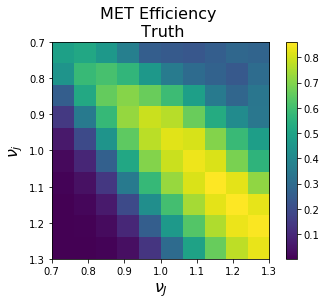

In [16]:
plt.title("MET Efficiency \n Truth", fontsize=16)
plt.imshow(y_test_sig.reshape(res, res), 
           origin='upper', 
           extent=[X_lower, X_upper, X_upper, X_lower])
plt.xlabel(r'$\nu_J$', fontsize=16)
plt.ylabel(r'$\nu_j$', fontsize=16)
plt.colorbar()
plt.savefig("truth_eff.png", bbox_inches='tight')

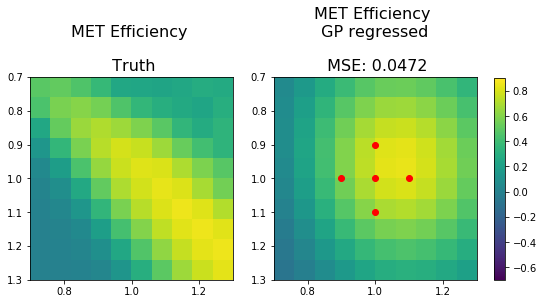

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
ax = axs.ravel()

kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train_sig)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test_sig)

max_val = 0.9
min_val = -0.7

axs[0].set_title("MET Efficiency \n \n Truth", fontsize=16)
axs[0].imshow(y_test_sig.reshape(res, res), 
              origin='upper', 
              extent=[X_lower, X_upper, X_upper, X_lower], 
              vmin=min_val, vmax=max_val)

axs[1].set_title("MET Efficiency \n GP regressed \n \n MSE: {:0.4f}".format(mse),
                 fontsize=16)
axs[1].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)
im = axs[1].imshow(mu.reshape(res, res), 
                   origin='upper', 
                   extent=[X_lower, X_upper, X_upper, X_lower],
                   vmin=min_val, vmax=max_val)

cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.show()

## Derivative-enhanced GPR

In [9]:
def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))

In [10]:
def dEff_MET50_sigmoid(J_scale, j_scale, 
              j1_threeM=j1_threeM, j2_threeM=j2_threeM, j3_threeM=j3_threeM):
    dmet_dj1 = 0
    dmet_dj2j3 = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            dsig = -dsigmoid(-(met-50.0))
            dmet = 0.5 / met

            # wrt J_scale 
            dj1  = -2*met_x*j1_threeM[i, 0] * np.cos(j1_threeM[i, 2]) / J_scale**2
            dj1 += -2*met_y*j1_threeM[i, 0] * np.sin(j1_threeM[i, 2]) / J_scale**2
            # wrt j_scale
            dj2j3  = -2*met_x*j2_threeM[i, 0] * np.cos(j2_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_x*j3_threeM[i, 0] * np.cos(j3_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_y*j2_threeM[i, 0] * np.sin(j2_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_y*j3_threeM[i, 0] * np.sin(j3_threeM[i, 2]) / j_scale**2

            dmet_dj1   += dsig * dmet * dj1
            dmet_dj2j3 += dsig * dmet * dj2j3

    return [dmet_dj1 / count_pTcut, dmet_dj2j3 / count_pTcut]


In [11]:
dX_train = X_train
dy_train_sig = np.array([dEff_MET50_sigmoid(dX_train[i][0], 
                                            dX_train[i][1]) for i in range(len(dX_train))])

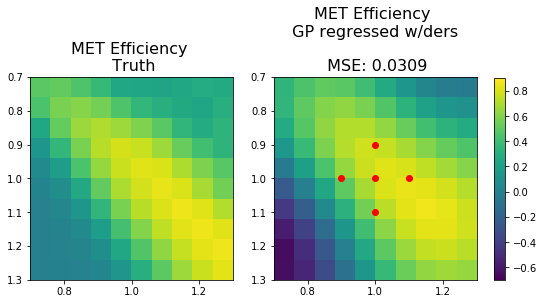

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
ax = axs.ravel()

kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train_sig, 
       dX=dX_train, dy=dy_train_sig)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test_sig)

max_val = 0.9
min_val = -0.7

axs[0].set_title("MET Efficiency \n Truth", fontsize=16)
axs[0].imshow(y_test_sig.reshape(res, res), 
              origin='upper', 
              extent=[X_lower, X_upper, X_upper, X_lower], 
              vmin=min_val, vmax=max_val)

axs[1].set_title("MET Efficiency \n GP regressed w/ders \n \n MSE: {:0.4f}".format(mse),
                 fontsize=16)
im = axs[1].imshow(mu.reshape(res, res), 
                   origin='upper', 
                   extent=[X_lower, X_upper, X_upper, X_lower],
                   vmin=min_val, vmax=max_val)
axs[1].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.show()

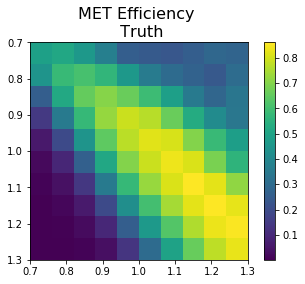

In [13]:
plt.title("MET Efficiency \n Truth", fontsize=16)
plt.imshow(y_test_sig.reshape(res, res), 
           origin='upper', 
           extent=[X_lower, X_upper, X_upper, X_lower], 
           vmin=min(y_test_sig), vmax=max(y_test_sig))
plt.colorbar()